In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris(as_frame=True)

df = iris.frame.copy()
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "target"]
df["species"] = df["target"].map(lambda x: f"Iris-{iris.target_names[x]}")
df = df.drop(columns=["target"])

df.to_csv("IRIS.csv", index=False)

print("IRIS.csv created successfully")
display(df.head())

IRIS.csv created successfully


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


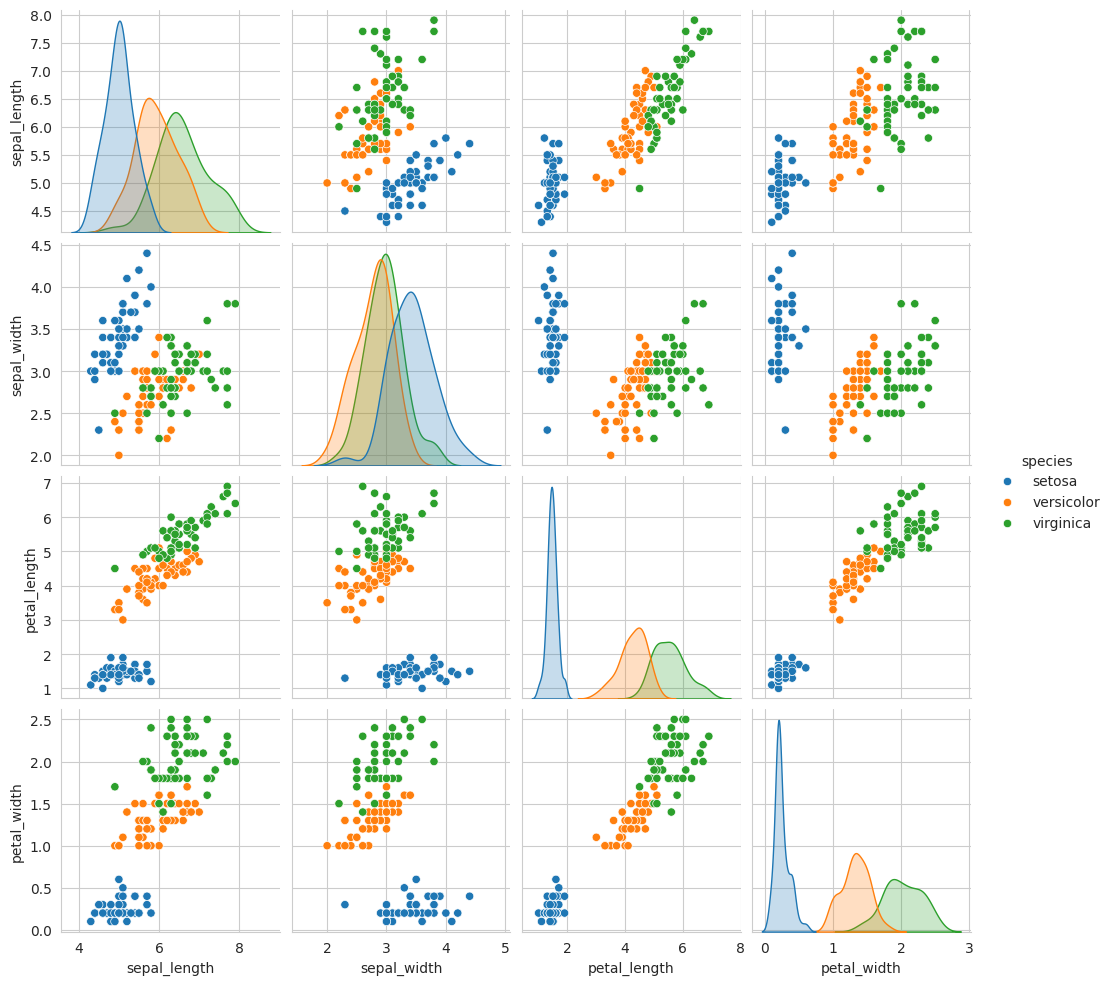

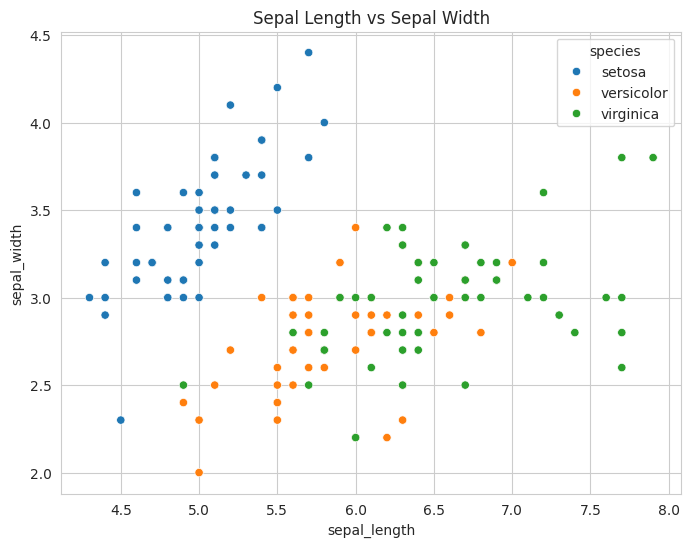

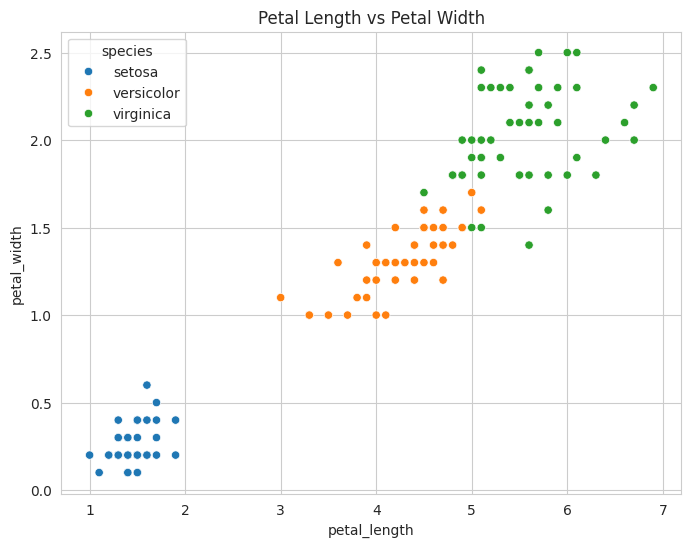

Train Shape: (120, 4)
Test Shape: (30, 4)
Accuracy: 0.9333333333333333

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



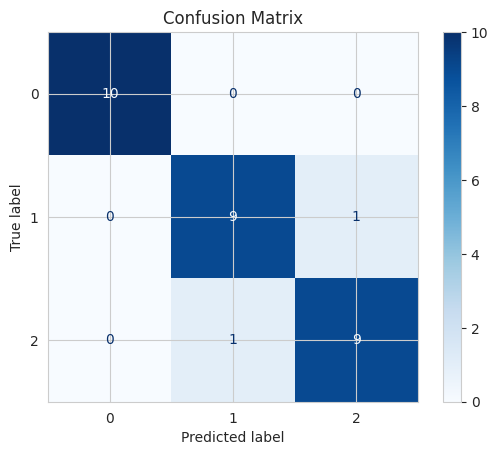

Model Saved Successfully


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")

# LOAD CSV
df = pd.read_csv("IRIS.csv")

print("Shape:", df.shape)

display(df.head())

print(df.info())

print(df.isnull().sum())

display(df.describe())

# CLEAN DATA
df["species"] = df["species"].str.replace(
    "Iris-",
    "",
    regex=False
)

print(df["species"].value_counts())

# PAIRPLOT
sns.pairplot(df, hue="species")

plt.show()

# SCATTER PLOT 1
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="sepal_length",
    y="sepal_width",
    hue="species"
)

plt.title("Sepal Length vs Sepal Width")

plt.show()

# SCATTER PLOT 2
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species"
)

plt.title("Petal Length vs Petal Width")

plt.show()

# LABEL ENCODING
le = LabelEncoder()

df["species_encoded"] = le.fit_transform(
    df["species"]
)

# FEATURES & TARGET
X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

y = df["species_encoded"]

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)

print("Test Shape:", X_test.shape)

# MODEL
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=500))
])

model.fit(X_train, y_train)

# PREDICTION
y_pred = model.predict(X_test)

# ACCURACY
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# SAVE MODEL
joblib.dump(
    model,
    "iris_model.pkl"
)

print("Model Saved Successfully")